# Night Image Segmentation using ACDC-SemSeg (Zagreb Model)

Pipeline for segmenting rectified 360° night images using a state-of-the-art
pretrained model (ranked #2 on ACDC benchmark with 80-82 % mIoU).

In [ ]:
# Verify GPU is enabled (Runtime → Change runtime type → T4 GPU)
!nvidia-smi

Sat Apr 18 17:36:46 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   44C    P8             13W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
# =====================================================
# One-time setup: clone repo, install packages, mount Drive
# =====================================================

# 1. Clone the segmentation model repo
%cd /content
!git clone https://github.com/UNIZG-FER-D307/semseg-in-adverse-conditions.git
%cd semseg-in-adverse-conditions

# 2. Install required packages
!pip install pytorch-lightning==2.0.6 einops==0.6.1 psutil==5.9.5 scipy opencv-python -q

# 3. Install open_clip from source
!git clone https://github.com/mlfoundations/open_clip.git -q
!cd open_clip && pip install -e . -q

# 4. Install timm (pytorch-image-models) from source
!git clone https://github.com/huggingface/pytorch-image-models.git -q
!cd pytorch-image-models && pip install -e . -q

# 5. Mount Google Drive
from google.colab import drive
drive.mount('/content/drive')

print("\n✅ Setup complete!")

/content
fatal: destination path 'semseg-in-adverse-conditions' already exists and is not an empty directory.
/content/semseg-in-adverse-conditions
fatal: destination path 'open_clip' already exists and is not an empty directory.
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for open_clip_torch (pyproject.toml) ... done
fatal: destination path 'pytorch-image-models' already exists and is not an empty directory.
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for timm (pyproject.toml) ... done
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).

✅ Setup co

In [ ]:
# =====================================================
# Copy checkpoint + input images from Drive to Colab
# =====================================================

CHECKPOINT_SRC = "/content/drive/MyDrive/night_seg_ckpts/sn-pyr_cn-lg_ud-320_best.ckpt"
IMAGES_SRC     = "/content/drive/MyDrive/night_images"

# Copy checkpoint into repo's expected location
!mkdir -p ckpts/model_single
!cp "{CHECKPOINT_SRC}" ckpts/model_single/

# Copy images into working folder
!rm -rf my_night_images
!mkdir -p my_night_images
!cp {IMAGES_SRC}/*.png my_night_images/

# Verify
print("Checkpoint:")
!ls -lh ckpts/model_single/
print("\nInput images:")
!ls -lh my_night_images/

Checkpoint:
total 2.3G
-rw------- 1 root root 2.3G Apr 18 17:37 sn-pyr_cn-lg_ud-320_best.ckpt

Input images:
total 4.2M
-rw------- 1 root root 1.1M Apr 18 17:37 rectified_back.png
-rw------- 1 root root 1.2M Apr 18 17:37 rectified_front.png
-rw------- 1 root root 772K Apr 18 17:37 rectified_left.png
-rw------- 1 root root 1.2M Apr 18 17:37 rectified_right.png


In [ ]:
# =====================================================
# Run prediction on rectified night images
# =====================================================

!python generate_predictions.py \
  -sv pyr \
  -bv large \
  --gpus 0 \
  --upsample_dims 320 \
  --ckpt_path ckpts/model_single/sn-pyr_cn-lg_ud-320_best.ckpt \
  --img_dir my_night_images

Selected GPUs: [0]
Loading single model...
['my_night_images/rectified_back.png', 'my_night_images/rectified_front.png', 'my_night_images/rectified_left.png', 'my_night_images/rectified_right.png']
> Found 4  images...
> Loaded <data.datasets.inference_data.inference_dataset.InferenceDataset object at 0x7fbc4d2a7cb0> images for predictions generation.
GPU available: True (cuda), used: True
TPU available: False, using: 0 TPU cores
IPU available: False, using: 0 IPUs
HPU available: False, using: 0 HPUs
2026-04-18 17:38:10.229916: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1776533890.455871    4331 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1776533890.521426    4331 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to reg

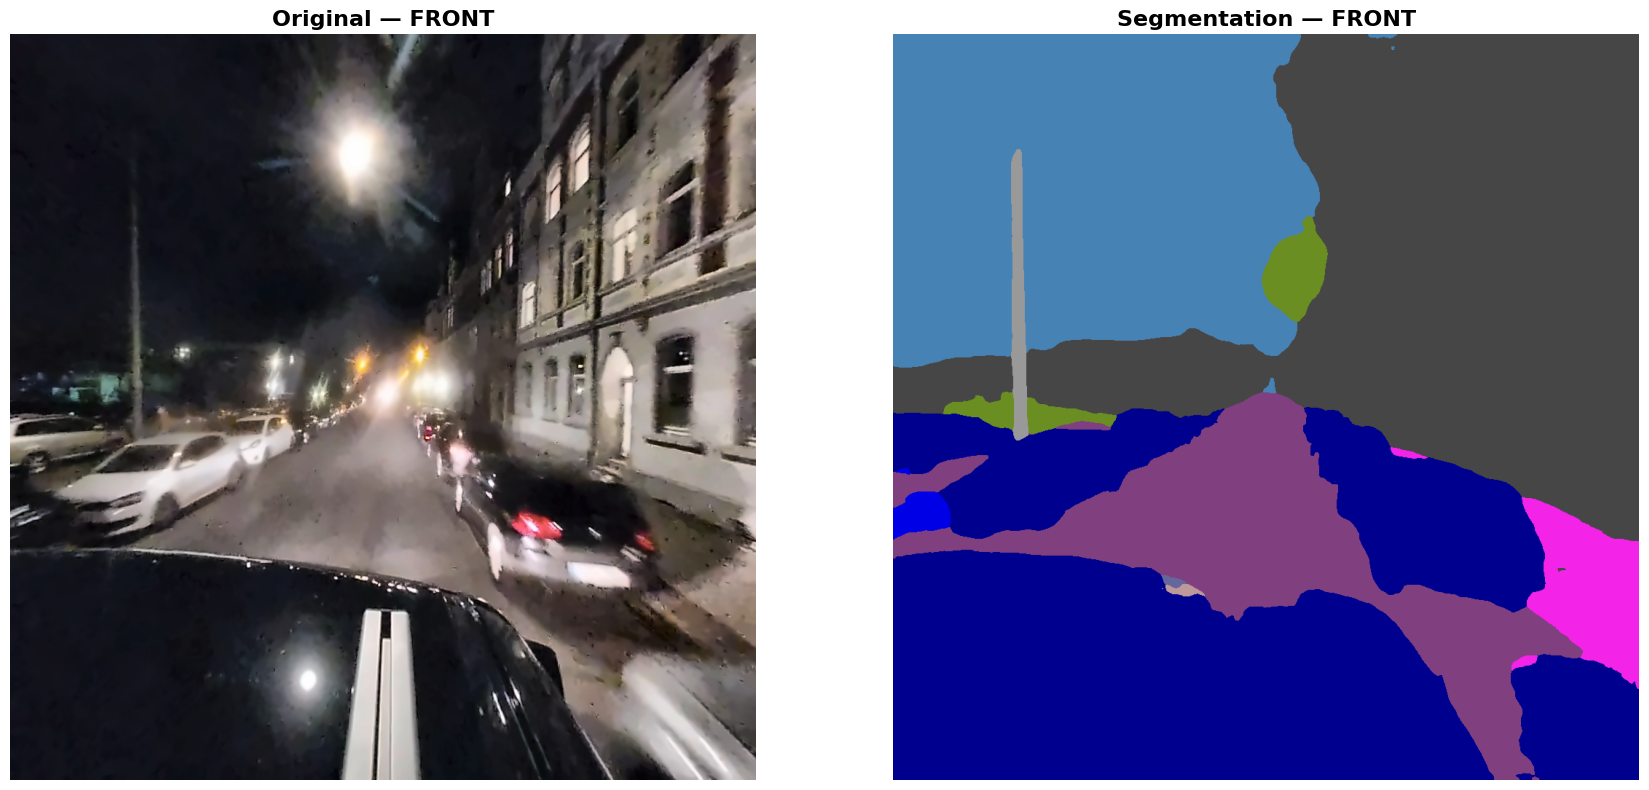

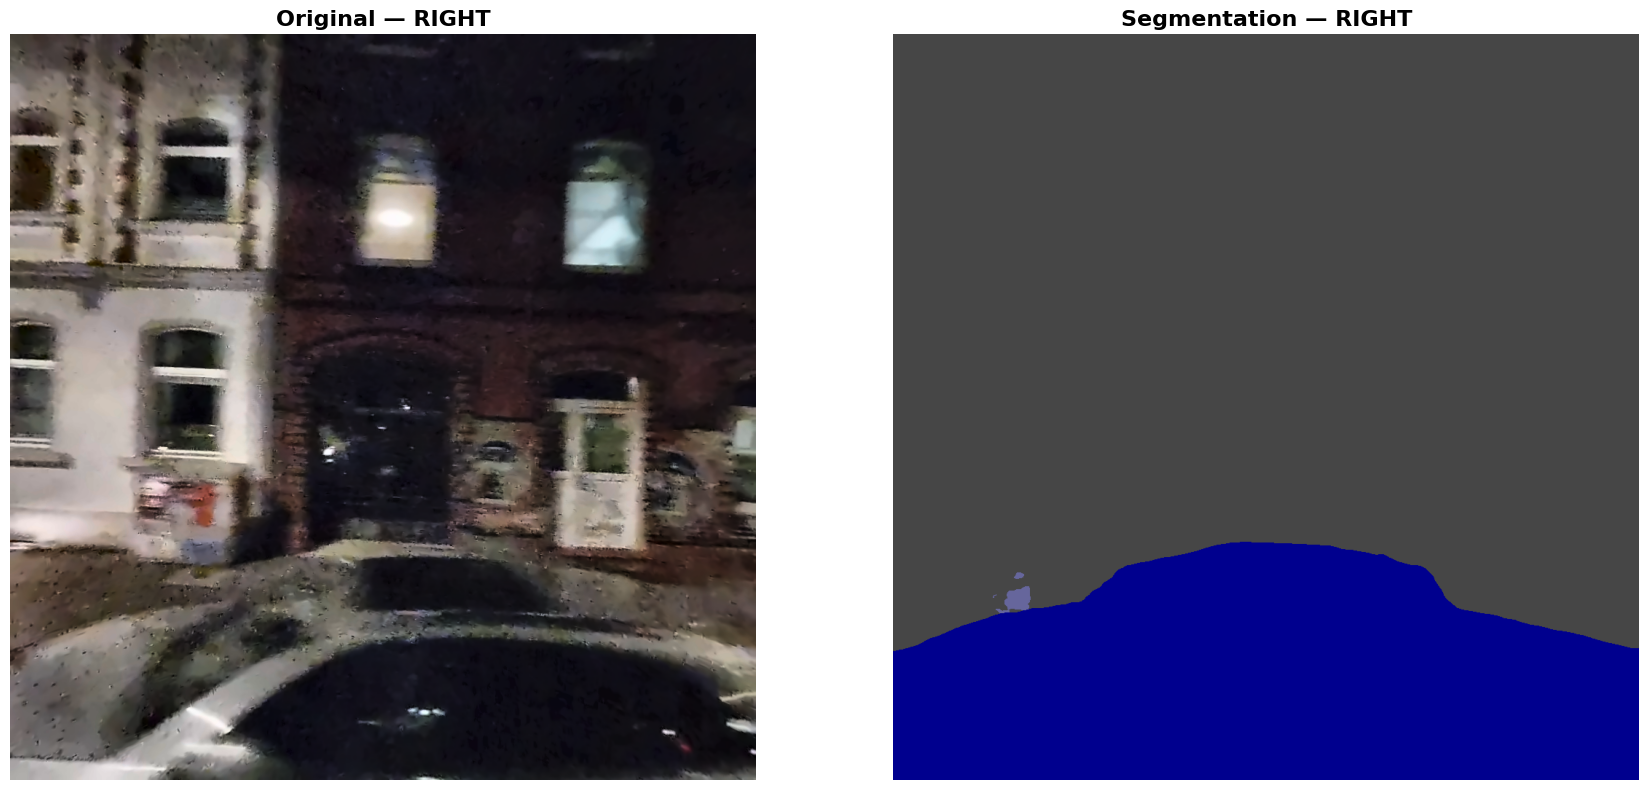

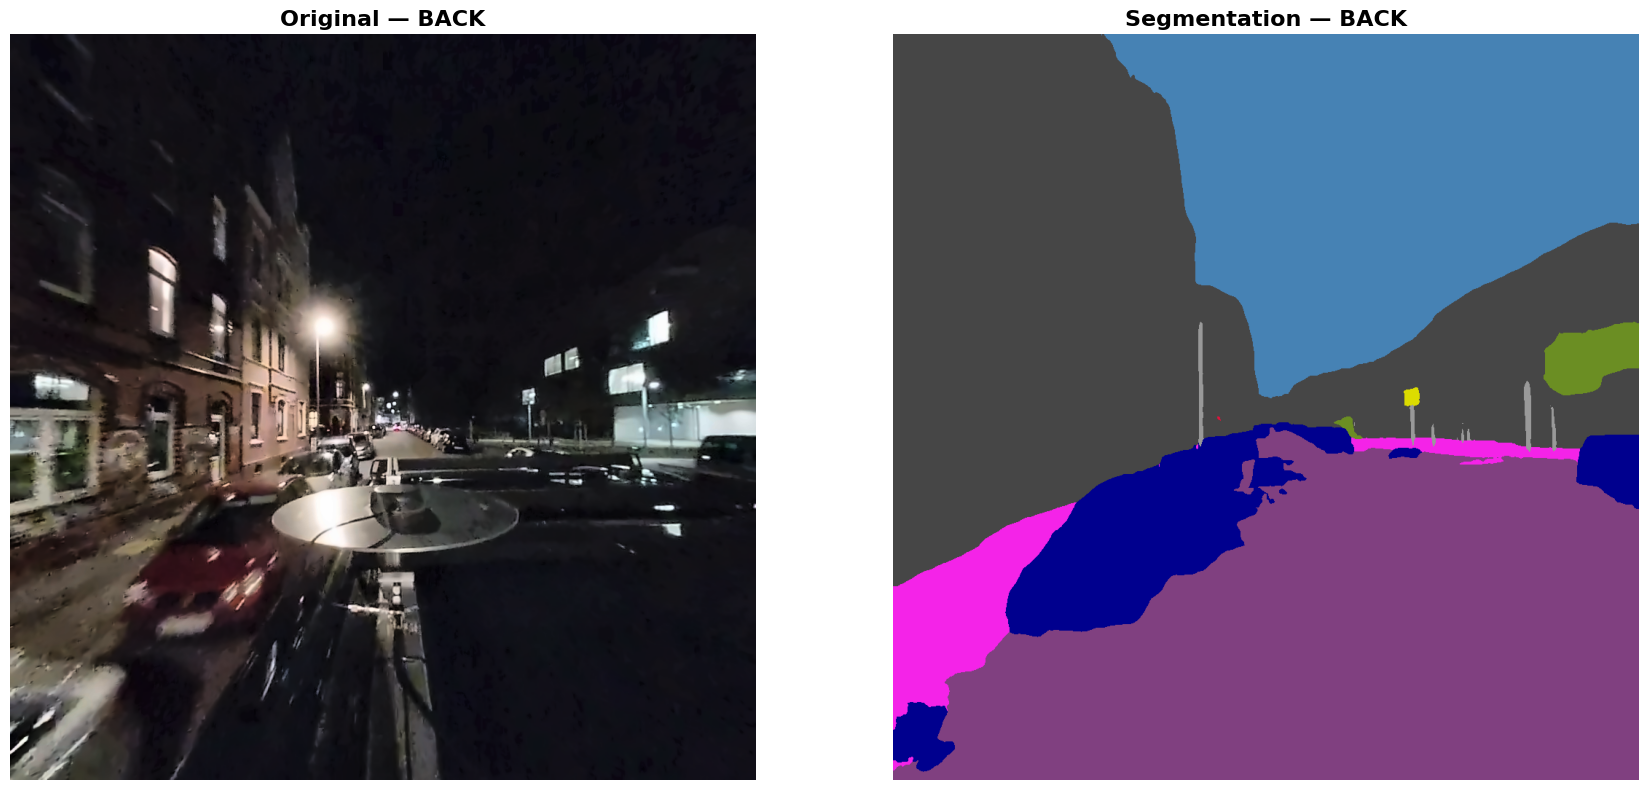

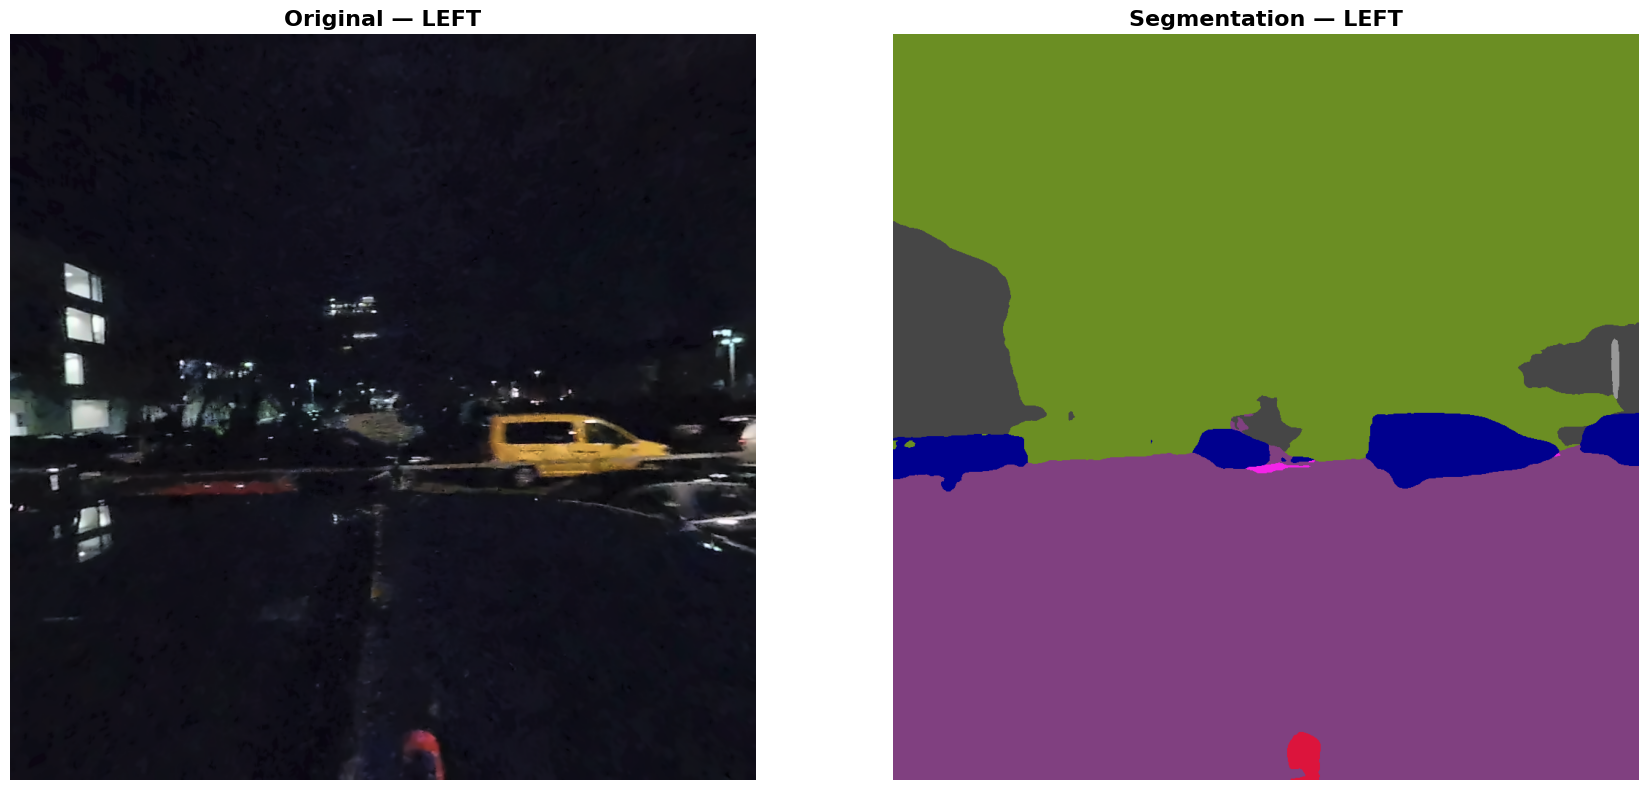

In [ ]:
# =====================================================
# Display originals next to their segmentations
# =====================================================

from PIL import Image as PILImage
import matplotlib.pyplot as plt
import os

original_dir  = 'my_night_images'
colorized_dir = 'output_pred_test/colorized'

views = ['front', 'right', 'back', 'left']

for view in views:
    orig_path = os.path.join(original_dir, f'rectified_{view}.png')
    pred_path = os.path.join(colorized_dir, f'rectified_{view}_pseudolabel.png')

    fig, axes = plt.subplots(1, 2, figsize=(18, 8))
    axes[0].imshow(PILImage.open(orig_path))
    axes[0].set_title(f'Original — {view.upper()}', fontsize=16, fontweight='bold')
    axes[0].axis('off')

    axes[1].imshow(PILImage.open(pred_path))
    axes[1].set_title(f'Segmentation — {view.upper()}', fontsize=16, fontweight='bold')
    axes[1].axis('off')

    plt.tight_layout()
    plt.show()

In [ ]:
# =====================================================
# Save results back to Google Drive for later analysis
# =====================================================

RESULTS_DIR = "/content/drive/MyDrive/night_segmentation_results"
!mkdir -p "{RESULTS_DIR}"
!cp -r output_pred_test/colorized           "{RESULTS_DIR}/"
!cp -r output_pred_test/pseudolabelTrainIds "{RESULTS_DIR}/"

print(f"✅ Results saved to: {RESULTS_DIR}")
!ls -lh "{RESULTS_DIR}/colorized/"

✅ Results saved to: /content/drive/MyDrive/night_segmentation_results
total 41K
-rw------- 1 root root  12K Apr 18 17:38 rectified_back_pseudolabel.png
-rw------- 1 root root  13K Apr 18 17:38 rectified_front_pseudolabel.png
-rw------- 1 root root 9.4K Apr 18 17:38 rectified_left_pseudolabel.png
-rw------- 1 root root 6.4K Apr 18 17:38 rectified_right_pseudolabel.png
